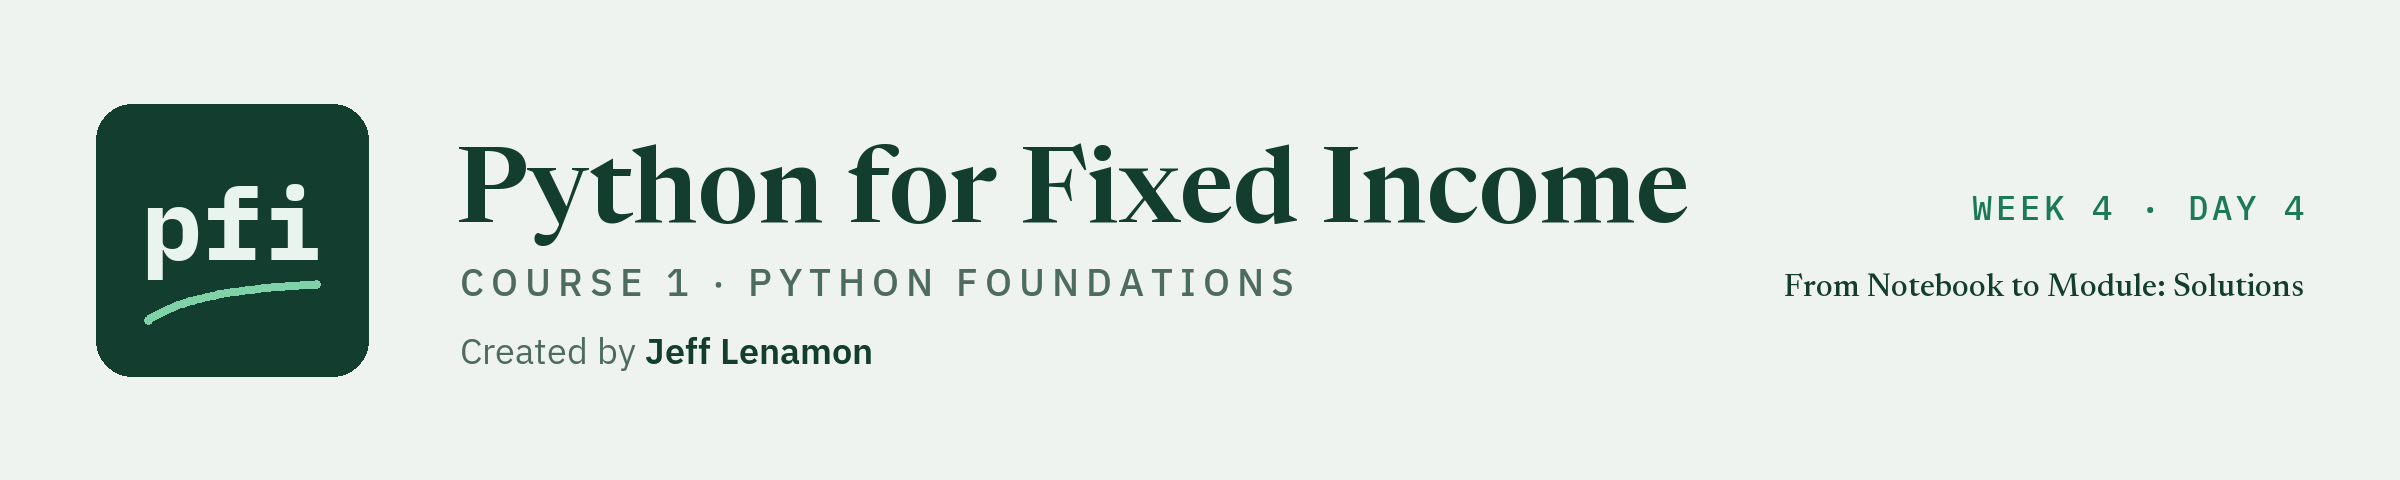

# From Notebook to Module - Solutions

Week 4. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day4/19_from_notebook_to_module_solutions.ipynb)

## Exercises

The exercises use the module and the two September files. The issuers are invented, and every answer describes the data and is not a view.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on, with f-strings. Worked answers are in the solutions notebook in this folder.

Run the next two cells first. The first writes `desk_tools.py` again, as the lesson left it, with its six functions and without the program block of section 19.9. The second imports it, defines `check`, a small function that marks your answers, loads the September extract as `raw`, and cleans it into `book`. It prints the shape of `raw`, (204, 19), the shape of `book`, (200, 20), and the market value of the book, 490,819,215.00 dollars.

In [1]:
%%writefile desk_tools.py
"""Desk tools: load, clean, check, summarize, and report a month-end holdings extract.

Written in notebook 19 of Python for Fixed Income. All portfolio data is synthetic.
"""
import pandas as pd


def load_holdings(path: str) -> pd.DataFrame:
    """Read a holdings extract from a CSV file and return it as it arrived.

    path is the file name or the web address of the CSV. The CUSIP is read as text.
    """
    return pd.read_csv(path, dtype={'cusip': str})


def clean_holdings(raw):
    """Apply the desk's cleaning decisions to an extract and return the cleaned table.

    The six decisions of week 3, day 3, in the same order:
      1. Exact duplicate rows are removed, keeping the first of each.
      2. Tickers are tidied: no spaces at either end, all capitals.
      3. A price dated on another day than the as-of date is flagged in a new column,
         stale_price. The price is not changed.
      4. A missing rating is labelled 'Not rated'. The bond stays in the book.
      5. A yield entered as a decimal is multiplied by 100. The test is the IQR rule:
         a yield below the first quartile less 1.5 times the IQR.
      6. Bonds with very wide spreads are real, and they are kept.

    raw is not changed. The cleaned table has one more column than raw: stale_price.
    """
    # work in a copy, so that the table passed in stays as it arrived
    book = raw.copy()

    # decision 1: remove the repeated rows and renumber the rows from 0
    book = book.drop_duplicates().reset_index(drop=True)

    # decision 2: tidy the tickers
    book['ticker'] = book['ticker'].str.strip().str.upper()

    # decision 3: flag the stale prices, and leave them as they are
    book['stale_price'] = book['price_date'] != book['as_of_date']

    # decision 4: label the missing ratings
    book['rating'] = book['rating'].fillna('Not rated')

    # decision 5: yields in percent, where one was entered as a decimal
    q1 = book['yield_pct'].quantile(0.25)
    q3 = book['yield_pct'].quantile(0.75)
    lower_limit = q1 - 1.5 * (q3 - q1)
    entered_as_decimal = book['yield_pct'] < lower_limit
    book.loc[entered_as_decimal, 'yield_pct'] = (book.loc[entered_as_decimal, 'yield_pct'] * 100).round(3)

    # decision 6: the very wide bonds are real and they stay, so there is no line for them

    return book


def check_totals(book, bonds, face, market_value):
    """Test a table against its three control totals. Raise ValueError if any one does not match.

    bonds is the number of rows the table should have. face and market_value are in dollars.
    Nothing is returned: if the function finishes without an error, the table matches.
    """
    found_bonds = len(book)
    found_face = book['par_held'].sum()
    found_value = book['market_value'].sum()

    # collect every mismatch, so that one message reports them all
    problems = []
    if found_bonds != bonds:
        problems.append(f'{found_bonds:,} rows against {bonds:,} bonds')
    if found_face != face:
        problems.append(f'face of {found_face:,} against {face:,} dollars')
    # market value has cents, so allow half a cent for decimal arithmetic
    if abs(found_value - market_value) > 0.005:
        problems.append(f'market value of {found_value:,.2f} against {market_value:,.2f} dollars')

    if problems:
        raise ValueError('control totals do not match: ' + '; '.join(problems))


def summarize(book):
    """Return the headline table of a cleaned book: one row, one column for each figure.

    face and market_value are in dollars, mean_oas in basis points, mean_yield in percent.
    not_rated and stale_prices count the bonds that clean_holdings labelled or flagged.
    """
    headline = {
        'bonds': len(book),
        'face': book['par_held'].sum(),
        'market_value': book['market_value'].sum(),
        'mean_oas': round(book['oas'].mean(), 2),
        'mean_yield': round(book['yield_pct'].mean(), 3),
        'not_rated': (book['rating'] == 'Not rated').sum(),
        'stale_prices': book['stale_price'].sum(),
    }
    # a list holding one dictionary becomes a table with one row
    return pd.DataFrame([headline])


def write_report(book, summary, path):
    """Write the month-end workbook to path: the headline table on a sheet named 'summary'
    and the cleaned book on a sheet named 'book'.
    """
    with pd.ExcelWriter(path) as writer:
        summary.to_excel(writer, sheet_name='summary', index=False)
        book.to_excel(writer, sheet_name='book', index=False)


def count_changes(raw, book):
    """Count what clean_holdings changed: one row, one column for each decision.

    raw is the extract as it arrived and book is the table clean_holdings returned for it.
    """
    # the extract with its repeated rows removed lines up row for row with the cleaned book
    kept = raw.drop_duplicates().reset_index(drop=True)
    counts = {
        'rows_removed': len(raw) - len(book),
        'tickers_tidied': (kept['ticker'] != book['ticker']).sum(),
        'stale_prices_flagged': book['stale_price'].sum(),
        'ratings_labelled': kept['rating'].isna().sum(),
        'yields_corrected': (kept['yield_pct'] != book['yield_pct']).sum(),
    }
    return pd.DataFrame([counts])

Writing desk_tools.py


In [2]:
# importlib reloads the module, os finds the data folder and deletes files, sys holds a Python setting
import importlib
import os
import sys

import pandas as pd

# no compiled copy of the module is kept, so the folder ends with the files it started with
sys.dont_write_bytecode = True

# import the module the cell above wrote. reload() makes sure the notebook is using that version.
import desk_tools
importlib.reload(desk_tools)


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(f'{label}: not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(f'{label}: correct')
    else:
        print(f'{label}: not yet. You have {answer}. Check the rounding the question asks for.')


# the data folder. In Colab the files are read from GitHub.
if os.path.exists('../../../data/holdings_messy.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# the control totals from the September cover note
expected_bonds = 200
expected_face = 489_000_000
expected_value = 490_819_215

# the September extract as received, and the cleaned book
raw = desk_tools.load_holdings(data_folder + 'holdings_messy.csv')
book = desk_tools.clean_holdings(raw)
desk_tools.check_totals(book, expected_bonds, expected_face, expected_value)

print(f'raw: {raw.shape}')
print(f'book: {book.shape}')
print(f"Market value of book: {book['market_value'].sum():,.2f} dollars")

raw: (204, 19)
book: (200, 20)
Market value of book: 490,819,215.00 dollars


### Exercise 1

Q. Add a function to the module. `sector_totals(book)` takes a cleaned book and returns the market value of each sector, in dollars, as a Series sorted from the largest sector to the smallest. Give it a docstring that says what goes in, what comes out, and the unit.

Write the function in the cell that starts with `%%writefile -a desk_tools.py`, under the comment, and run that cell once. Then reload the module, call the function on `book`, and store the name of the largest sector in **ex1_sector** and its market value in **ex1_value**.

In [3]:
%%writefile -a desk_tools.py


def sector_totals(book):
    """Return the market value of each sector of a book, in dollars, largest sector first.

    book is a table with a sector column and a market_value column. A Series comes back,
    with the sector names as its labels.
    """
    totals = book.groupby('sector')['market_value'].sum()
    return totals.sort_values(ascending=False)

Appending to desk_tools.py


In [4]:
# the file changed, so reload before calling the new function
importlib.reload(desk_tools)

totals = desk_tools.sector_totals(book)
print(totals)

# the first label of the sorted Series, and the first value
ex1_sector = totals.index[0]
ex1_value = totals.iloc[0]

print(f'Largest sector: {ex1_sector}, {ex1_value:,.2f} dollars')
print(f'Sum of the sectors: {totals.sum():,.2f} dollars')

sector
Materials         71701617.5
Financials        68219672.5
Consumer          56629597.5
Telecom           55848270.0
Industrials       52540745.0
Transportation    48822897.5
Health Care       38908187.5
Energy            38830005.0
Technology        30311760.0
Utilities         29006462.5
Name: market_value, dtype: float64
Largest sector: Materials, 71,701,617.50 dollars
Sum of the sectors: 490,819,215.00 dollars


* Materials is the largest sector of the cleaned September book, with 71,701,617.50 dollars of market value. Financials is second with 68,219,672.50 and Consumer third with 56,629,597.50.
* The ten sectors add up to 490,819,215.00 dollars, the control total. A grouped table that does not add up to the book has lost rows.
* Without the reload the call fails with an `AttributeError`, as in section 19.5.
* The cell is run once. `-a` appends each time it runs, so a second run would put a second copy of the function in the file. Python would use the later one, and the file would be untidy.

In [5]:
check('Exercise 1 largest sector', ex1_sector, 'Materials')
check('Exercise 1 market value', ex1_value, 71701617.5)

Exercise 1 largest sector: correct
Exercise 1 market value: correct


### Exercise 2

Q. Write a check that raises. `check_unique(table, column)` counts the values of `column` that repeat an earlier value. If there are none it does nothing. If there are any it raises `ValueError` with the message `N repeated values in COLUMN`, where N is the count and COLUMN is the column's name, for example `3 repeated values in ticker`.

Define it in a notebook cell, with a docstring. Call it on `book` and the `cusip` column, which should pass. Then call it on `raw` and the `cusip` column inside `try` and `except`, and store the text of the error, `str(error)`, in **ex2_message**.

In [6]:
def check_unique(table, column):
    """Raise ValueError if any value of the column repeats an earlier one. Return nothing otherwise."""
    # duplicated() marks a value True when it has appeared before
    repeats = table[column].duplicated().sum()
    if repeats > 0:
        raise ValueError(f'{repeats} repeated values in {column}')


# the cleaned book: no error, so the print is reached
check_unique(book, 'cusip')
print('book: every CUSIP appears once')

# the extract as received: catch the error and keep its message
try:
    check_unique(raw, 'cusip')
    ex2_message = 'no error'
except ValueError as error:
    ex2_message = str(error)

print(f'raw: {ex2_message}')

book: every CUSIP appears once
raw: 4 repeated values in cusip


* The cleaned book passes without a word. The extract as received raises, and the message is `4 repeated values in cusip`: the four rows sent twice.
* `str(error)` is the message that was given to `ValueError`. Writing the count and the column name into the message means the person who sees the error knows where to look.
* The line `ex2_message = 'no error'` inside the `try` runs only if the check did not raise. Without it, a check that wrongly passed would leave `ex2_message` undefined.

In [7]:
check('Exercise 2 message', ex2_message, '4 repeated values in cusip')

Exercise 2 message: correct


### Exercise 3

Q. Run the month end on the other file. With the module's functions, load `holdings.csv`, clean it, check it against the control totals, summarize it, and write the report to a workbook called `exercise_report.xlsx`. Read the `book` sheet and the `summary` sheet back from the workbook, then delete the workbook.

Store the number of rows on the `book` sheet in **ex3_rows**, the mean yield on the `summary` sheet, in percent, in **ex3_yield**, the number of stale prices on the `summary` sheet in **ex3_stale**, and whether the workbook still exists after you delete it, True or False, in **ex3_left**.

In [8]:
report_file = 'exercise_report.xlsx'

# the same five lines as the lesson, on the clean September file
raw_clean = desk_tools.load_holdings(data_folder + 'holdings.csv')
book_clean = desk_tools.clean_holdings(raw_clean)
desk_tools.check_totals(book_clean, expected_bonds, expected_face, expected_value)
summary_clean = desk_tools.summarize(book_clean)
desk_tools.write_report(book_clean, summary_clean, report_file)

# read both sheets back
book_back = pd.read_excel(report_file, sheet_name='book', dtype={'cusip': str})
summary_back = pd.read_excel(report_file, sheet_name='summary')

ex3_rows = len(book_back)
ex3_yield = summary_back.loc[0, 'mean_yield']
ex3_stale = summary_back.loc[0, 'stale_prices']

# delete the workbook and confirm
os.remove(report_file)
ex3_left = os.path.exists(report_file)

print(f'Rows on the book sheet: {ex3_rows:,}')
print(f'Mean yield on the summary sheet: {ex3_yield} percent')
print(f'Stale prices on the summary sheet: {ex3_stale}')
print(f'Workbook still exists: {ex3_left}')
print(desk_tools.count_changes(raw_clean, book_clean))

Rows on the book sheet: 200
Mean yield on the summary sheet: 6.088 percent
Stale prices on the summary sheet: 0
Workbook still exists: False
   rows_removed  tickers_tidied  stale_prices_flagged  ratings_labelled  \
0             0               0                     0                 0   

   yields_corrected  
0                 0  


* 200 rows on the `book` sheet, a mean yield of 6.088 percent, and 0 stale prices. The workbook is gone after `os.remove()`.
* The only thing that changed from the lesson's run was the file name. `count_changes` shows five zeros: the routine left the clean file alone.
* The mean yield, 6.088 percent, is the one the cleaned messy extract gave. Two routes to the same book arrive at the same figure.

In [9]:
check('Exercise 3 rows on the book sheet', ex3_rows, 200)
check('Exercise 3 mean yield', ex3_yield, 6.088)
check('Exercise 3 stale prices', ex3_stale, 0)
check('Exercise 3 workbook left behind', ex3_left, False)

Exercise 3 rows on the book sheet: correct
Exercise 3 mean yield: correct
Exercise 3 stale prices: correct
Exercise 3 workbook left behind: correct


### Exercise 4: AI check

You ask an AI assistant for one more function for the module: the average OAS of a book, weighted by market value. It gives you the function below. It was written for this course in the style of an AI assistant's answer. It has a docstring, it runs without an error, and it contains one bug.

Before a function goes into the module, it is tested. The cell also builds a table of two bonds for that purpose.

Q. Read the function before you run the cell. Work out by hand what the weighted average OAS of the two bonds in `two_bonds` should be. Then run the cell. Does the answer agree with you?

* The two bonds have the same market value, 1,000,000 dollars each, so the average weighted by market value is the simple average of 900 and 100: 500 basis points.
* The original function returned 633.33 for the two bonds and 184.52 for the book, with no error and no warning. 184.52 basis points is a plausible figure for this book, and nothing about it looks wrong.
* The bug was the weight. The docstring says market value, and the code multiplied by `par_held` and divided by the sum of `par_held`: an average weighted by face. In the test table the first bond has 2,000,000 dollars of face at a price near 50, so by face it counts twice and by market value it counts once.
* The assert test caught it: `assert weighted_mean_oas(two_bonds) == 500` fails on the original. The fix is to use `market_value` in both places. The corrected figure for the book is 180.46 basis points, 4.06 lower.
* The docstring and the code disagreed, and only a test on a table with a known answer could say which the function really did.

In [10]:
def weighted_mean_oas(book):
    """Return the average OAS of a book in basis points, weighted by market value."""
    # weight each bond's OAS by its market value
    weighted_sum = (book['oas'] * book['market_value']).sum()
    return weighted_sum / book['market_value'].sum()


# a test table with a known answer: equal market values, so the answer is the simple average
two_bonds = pd.DataFrame({
    'oas': [900, 100],
    'par_held': [2_000_000, 1_000_000],
    'market_value': [1_000_000.0, 1_000_000.0],
})

# the test: this line fails on the function as the assistant wrote it
assert weighted_mean_oas(two_bonds) == 500, f'expected 500, found {weighted_mean_oas(two_bonds)}'

ex4_two_bonds = weighted_mean_oas(two_bonds)
ex4_book = round(weighted_mean_oas(book), 2)

print(f'Two bonds: {ex4_two_bonds:,.2f} basis points')
print(f'Cleaned September book: {ex4_book:,.2f} basis points')

Two bonds: 500.00 basis points
Cleaned September book: 180.46 basis points


In [11]:
check('Exercise 4 two bonds', ex4_two_bonds, 500.0)
check('Exercise 4 the book', ex4_book, 180.46)

Exercise 4 two bonds: correct
Exercise 4 the book: correct


### Tidying up

The lesson deleted its report workbook, and Exercise 3 deletes its own. The module is the last file left. In this course every file a notebook writes is removed by the notebook, so the last cell deletes `desk_tools.py`. On a desk you would keep it: the module is the point. The course project asks you to write your own.

In [12]:
# delete every file this notebook wrote, if it is still there
for file in ['desk_tools.py', 'month_end_report.xlsx', 'exercise_report.xlsx']:
    if os.path.exists(file):
        os.remove(file)
    print(f'{file} exists: {os.path.exists(file)}')

desk_tools.py exists: False
month_end_report.xlsx exists: False
exercise_report.xlsx exists: False
